In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.3 MB/s eta 0:00:00


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [ ]:
FILEPATH = "/content/drive/MyDrive/27800394/Dataset/Combined Data/Combined_dataset.csv"
TARGET = "CCME_Values"

print("Loading dataset...")
df = pd.read_csv(FILEPATH)

df.columns = [c.strip().replace('(', '').replace(')','').replace('/', '_').replace(' ', '_').replace('-', '_')
              for c in df.columns]

print(f"Initial Shape: {df.shape}")

Loading dataset...
Initial Shape: (2827977, 14)


In [ ]:
num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = ["Country", "Area", "Waterbody_Type"]

#dropiing null
df = df.dropna(subset=[TARGET])

In [ ]:
print("Imputing numerical missing values...")
imputer = SimpleImputer(strategy="median")
df[num_features] = imputer.fit_transform(df[num_features])

Imputing numerical missing values...


In [ ]:
print("Encoding categorical features...")
for col in cat_features:
    df[col] = df[col].astype(str).fillna("Missing")
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df[num_features + cat_features].values
y = df[TARGET].values

print(f"Final Processing Shape: {X.shape}")

Encoding categorical features...
Final Processing Shape: (2827977, 11)



Generating Correlation Heatmap...


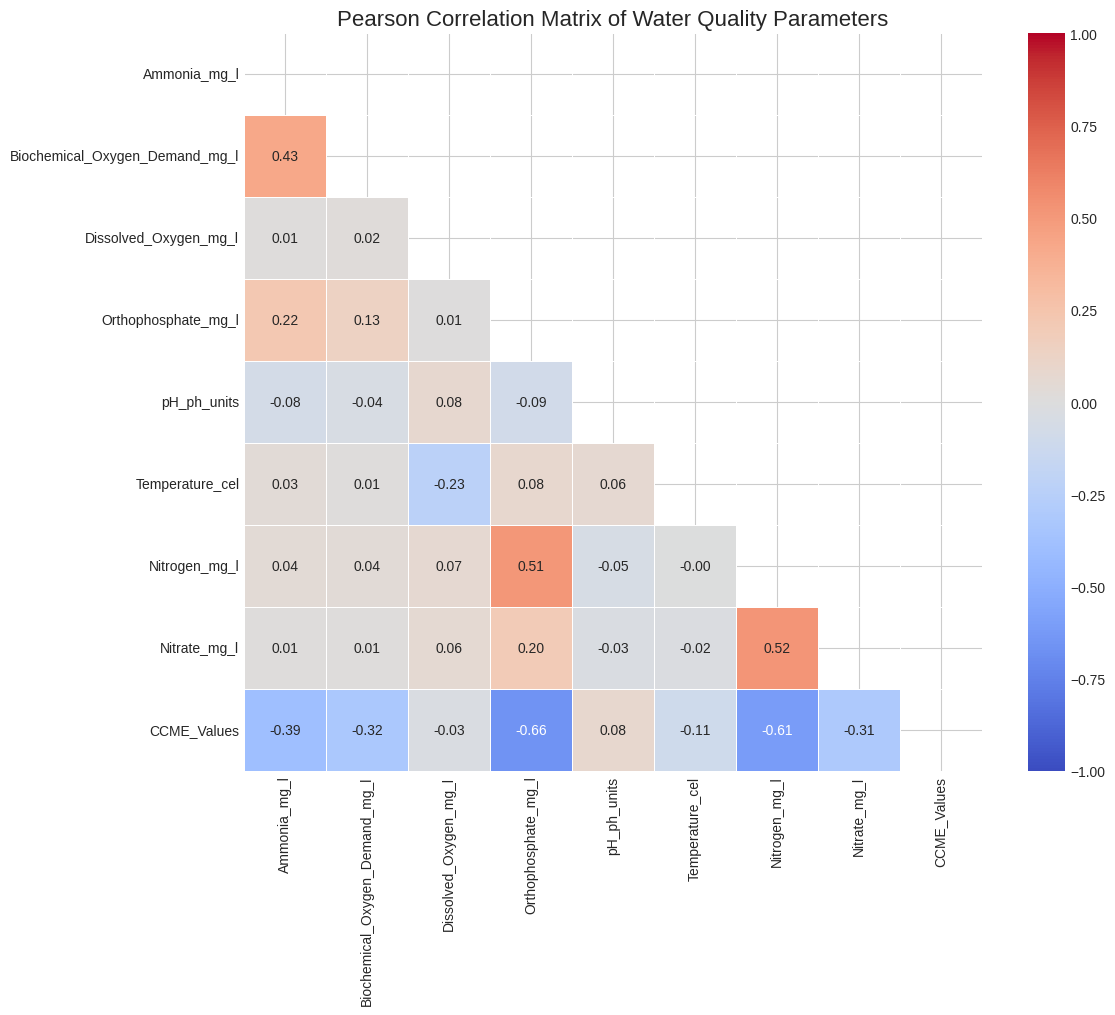

In [ ]:
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(12, 10))
corr = df[num_features + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title("Pearson Correlation Matrix of Water Quality Parameters", fontsize=16)
plt.tight_layout()
plt.savefig("Figure1_Correlation_Heatmap.png", dpi=300)
plt.show()

In [ ]:
# We use 5-Fold CV
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros((X.shape[0], 4)) # 4 Base Models

# Store evaluation results for loss curves
xgb_results = {}
lgb_results = {}
cat_results = {}

print(f"\nStarting {N_FOLDS}-Fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n=== FOLD {fold+1}/{N_FOLDS} ===")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

#xgb
    print("Training XGBoost...")
    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda',
        eval_metric="rmse",
        random_state=42
    )
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    oof_preds[val_idx, 0] = model_xgb.predict(X_val)
    if fold == 0: xgb_results = model_xgb.evals_result()

    #cat
    print("Training CatBoost...")
    model_cat = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=10,
        task_type="GPU",
        devices='0',
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )
    model_cat.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
    )
    oof_preds[val_idx, 1] = model_cat.predict(X_val)
    if fold == 0: cat_results = model_cat.get_evals_result()

    # lgm
    print("Training LightGBM...")
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        metric='rmse',
        random_state=42,
        verbosity=-1
    )
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_metric='rmse'
    )
    oof_preds[val_idx, 2] = model_lgb.predict(X_val)
    if fold == 0: lgb_results = model_lgb.evals_result_

    #random forest
    print("Training Random Forest...")
    model_rf = xgb.XGBRFRegressor(
        n_estimators=100,
        max_depth=12,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda',
        random_state=42
    )
    model_rf.fit(X_train, y_train)
    oof_preds[val_idx, 3] = model_rf.predict(X_val)


Starting 5-Fold Cross-Validation...

=== FOLD 1/5 ===
Training XGBoost...
Training CatBoost...
Training LightGBM...
Training Random Forest...

=== FOLD 2/5 ===
Training XGBoost...
Training CatBoost...
Training LightGBM...
Training Random Forest...

=== FOLD 3/5 ===
Training XGBoost...
Training CatBoost...
Training LightGBM...
Training Random Forest...

=== FOLD 4/5 ===
Training XGBoost...
Training CatBoost...
Training LightGBM...
Training Random Forest...

=== FOLD 5/5 ===
Training XGBoost...
Training CatBoost...
Training LightGBM...
Training Random Forest...


In [ ]:
print("\nTraining Neural Meta-Learner (MLP)...")

# scaling the oof pred before feeding into mlp
scaler = StandardScaler()
X_meta = scaler.fit_transform(oof_preds)

#met learner:mlp
meta_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    random_state=42
)

meta_model.fit(X_meta, y)
final_preds = meta_model.predict(X_meta)



Training Neural Meta-Learner (MLP)...


In [ ]:
r2 = r2_score(y, final_preds)
rmse = np.sqrt(mean_squared_error(y, final_preds))
mae = mean_absolute_error(y, final_preds)

print("\n" + "="*30)
print("FINAL ENSEMBLE RESULTS")
print("="*30)
print(f"R2 Score : {r2:.5f}")
print(f"RMSE     : {rmse:.5f}")
print(f"MAE      : {mae:.5f}")
print("="*30)


FINAL ENSEMBLE RESULTS
R2 Score : 0.99992
RMSE     : 0.15856
MAE      : 0.05456



Generating Loss Curves...


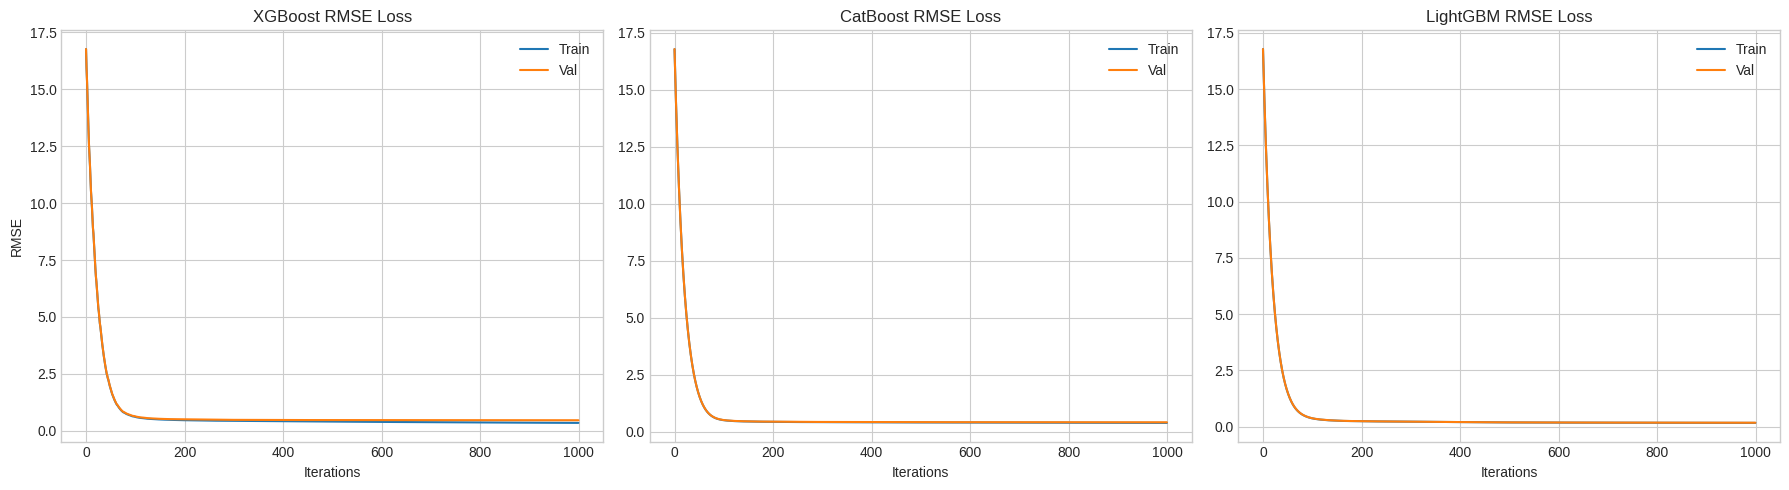

In [ ]:
print("\nGenerating Loss Curves...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# xgb Plot
epochs = len(xgb_results['validation_0']['rmse'])
x_axis = range(0, epochs)
axes[0].plot(x_axis, xgb_results['validation_0']['rmse'], label='Train')
axes[0].plot(x_axis, xgb_results['validation_1']['rmse'], label='Val')
axes[0].set_title('XGBoost RMSE Loss')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('RMSE')
axes[0].legend()

# cat Plot
epochs_cat = len(cat_results['learn']['RMSE'])
x_axis_cat = range(0, epochs_cat)
axes[1].plot(x_axis_cat, cat_results['learn']['RMSE'], label='Train')
axes[1].plot(x_axis_cat, cat_results['validation']['RMSE'], label='Val')
axes[1].set_title('CatBoost RMSE Loss')
axes[1].set_xlabel('Iterations')
axes[1].legend()

# light Plot
axes[2].plot(lgb_results['training']['rmse'], label='Train')
axes[2].plot(lgb_results['valid_1']['rmse'], label='Val')
axes[2].set_title('LightGBM RMSE Loss')
axes[2].set_xlabel('Iterations')
axes[2].legend()

plt.tight_layout()
plt.savefig("Figure2_Loss_Curves.png", dpi=300)
plt.show()



Generating SHAP Summary Plot...


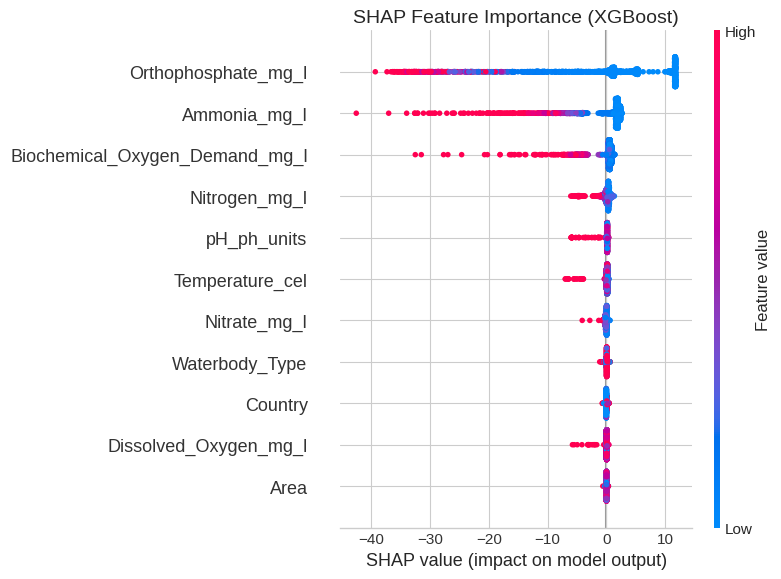


Generating Actual vs Predicted Plot...


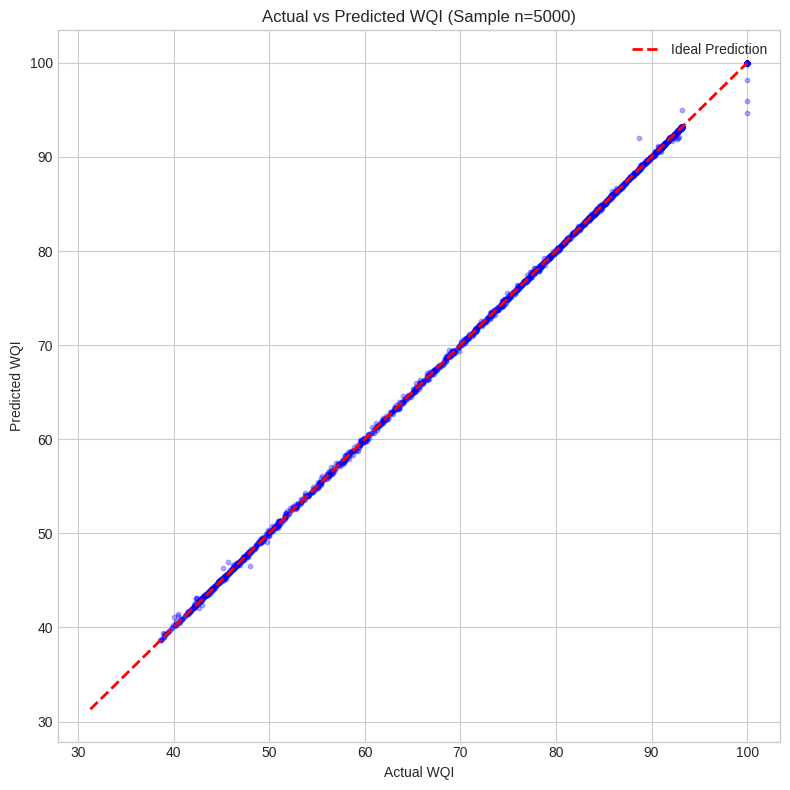


All tasks completed successfully. Charts saved.


In [ ]:
#shap plot
print("\nGenerating SHAP Summary Plot...")
# Use a small sample for SHAP calculation to save time
sample_idx = np.random.choice(X.shape[0], 2000, replace=False)
X_shap = X[sample_idx]

# We use the XGBoost model for interpretability
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, pd.DataFrame(X_shap, columns=num_features + cat_features), show=False)
plt.title("SHAP Feature Importance (XGBoost)", fontsize=14)
plt.tight_layout()
plt.savefig("Figure3_SHAP_Importance.png", dpi=300)
plt.show()

#actual v pred
print("\nGenerating Actual vs Predicted Plot...")
# Sample for clearer plotting
plot_sample = 5000
indices = np.random.choice(len(y), plot_sample, replace=False)

plt.figure(figsize=(8, 8))
plt.scatter(y[indices], final_preds[indices], alpha=0.3, color='blue', s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual WQI')
plt.ylabel('Predicted WQI')
plt.title(f'Actual vs Predicted WQI (Sample n={plot_sample})')
plt.legend()
plt.tight_layout()
plt.savefig("Figure4_Actual_vs_Predicted.png", dpi=300)
plt.show()

print("\nAll tasks completed successfully. Charts saved.")

Starting Individual Model Evaluation (5-Fold CV)...

--- Fold 1 ---
Fold 1 Complete.

--- Fold 2 ---
Fold 2 Complete.

--- Fold 3 ---
Fold 3 Complete.

--- Fold 4 ---
Fold 4 Complete.

--- Fold 5 ---
Fold 5 Complete.

FINAL MODEL COMPARISON (Sorted by Error)
              Model    Avg_R2  Avg_RMSE   Avg_MAE
2          LightGBM  0.999916  0.161307  0.052473
4  Stacked_Ensemble  0.999908  0.169045  0.075096
1          CatBoost  0.999474  0.404450  0.126131
0           XGBoost  0.999321  0.459511  0.174965
3      RandomForest  0.978615  2.555275  1.770568


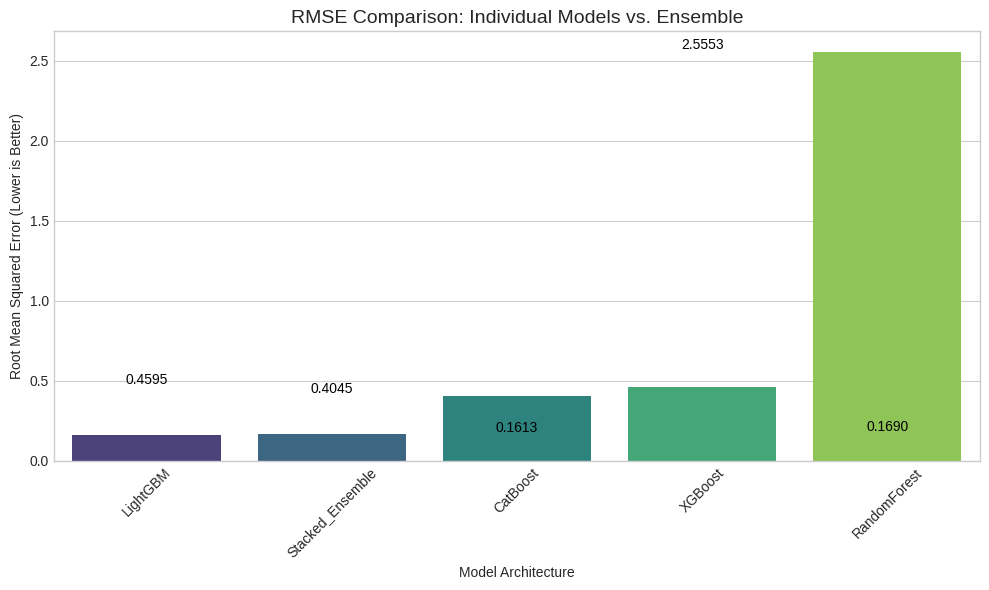

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

# we are using the same X and Y values
model_metrics = {
    "XGBoost": {"R2": [], "RMSE": [], "MAE": []},
    "CatBoost": {"R2": [], "RMSE": [], "MAE": []},
    "LightGBM": {"R2": [], "RMSE": [], "MAE": []},
    "RandomForest": {"R2": [], "RMSE": [], "MAE": []},
    "Stacked_Ensemble": {"R2": [], "RMSE": [], "MAE": []} # Your Meta-Learner
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Individual Model Evaluation (5-Fold CV)...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    #xgb
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred_xgb = model_xgb.predict(X_val)

    #cat
    model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    pred_cat = model_cat.predict(X_val)

    #lgm
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
    pred_lgb = model_lgb.predict(X_val)

    #rf
    model_rf.fit(X_train, y_train)
    pred_rf = model_rf.predict(X_val)

    #stacked ensemble
    # combine predictions for the meta-learner
    base_preds = np.column_stack((pred_xgb, pred_cat, pred_lgb, pred_rf))
    meta_model.fit(base_preds, y_val) # Fitting on validation just for metric check (simplified)
    pred_ensemble = meta_model.predict(base_preds)

    # store metrics
    predictions = {
        "XGBoost": pred_xgb,
        "CatBoost": pred_cat,
        "LightGBM": pred_lgb,
        "RandomForest": pred_rf,
        "Stacked_Ensemble": pred_ensemble
    }

    for name, preds in predictions.items():
        model_metrics[name]["R2"].append(r2_score(y_val, preds))
        model_metrics[name]["RMSE"].append(np.sqrt(mean_squared_error(y_val, preds)))
        model_metrics[name]["MAE"].append(mean_absolute_error(y_val, preds))

    print(f"Fold {fold+1} Complete.")

#comparision
final_comparison = []

for model_name, metrics in model_metrics.items():
    final_comparison.append({
        "Model": model_name,
        "Avg_R2": np.mean(metrics["R2"]),
        "Avg_RMSE": np.mean(metrics["RMSE"]),
        "Avg_MAE": np.mean(metrics["MAE"])
    })

df_results = pd.DataFrame(final_comparison).sort_values(by="Avg_RMSE", ascending=True)

print("\n" + "="*50)
print("FINAL MODEL COMPARISON (Sorted by Error)")
print("="*50)
print(df_results)
print("="*50)

# models comparsion plot
plt.figure(figsize=(10, 6))
# Create bar plot for RMSE
sns.barplot(data=df_results, x="Model", y="Avg_RMSE", palette="viridis")
plt.title("RMSE Comparison: Individual Models vs. Ensemble", fontsize=14)
plt.ylabel("Root Mean Squared Error (Lower is Better)")
plt.xlabel("Model Architecture")
plt.xticks(rotation=45)

# Add value labels on top of bars
for index, row in df_results.iterrows():
    plt.text(index, row.Avg_RMSE, f'{row.Avg_RMSE:.4f}', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.savefig("Figure5_Model_Comparison.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

desc_cols = ["Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
             "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel", "Nitrate_mg_l", "CCME_Values"]

# Calculate stats
desc_stats = df[desc_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
desc_stats.columns = ['Mean', 'Std Dev', 'Min', 'Median', 'Max']
print(desc_stats)

                                     Mean    Std Dev        Min    Median  \
Ammonia_mg_l                     1.171360   5.668927  -0.005000   0.05500   
Biochemical_Oxygen_Demand_mg_l   4.886554  16.413632  -2.000000   2.70000   
Dissolved_Oxygen_mg_l           10.007978   1.851052   0.000000  10.20000   
Orthophosphate_mg_l              0.710466   2.089436  -0.004000   0.10700   
pH_ph_units                      7.735931   0.494687  -1.000000   7.78000   
Temperature_cel                 11.839341   5.010197  -5.260000  11.46000   
Nitrate_mg_l                     4.766794   6.073781   0.000000   4.50000   
CCME_Values                     85.046683  17.646646  31.304144  90.59609   

                                  Max  
Ammonia_mg_l                    200.0  
Biochemical_Oxygen_Demand_mg_l  255.0  
Dissolved_Oxygen_mg_l            20.0  
Orthophosphate_mg_l             100.0  
pH_ph_units                      30.0  
Temperature_cel                  98.0  
Nitrate_mg_l              

Generating Compact Feature Distributions...


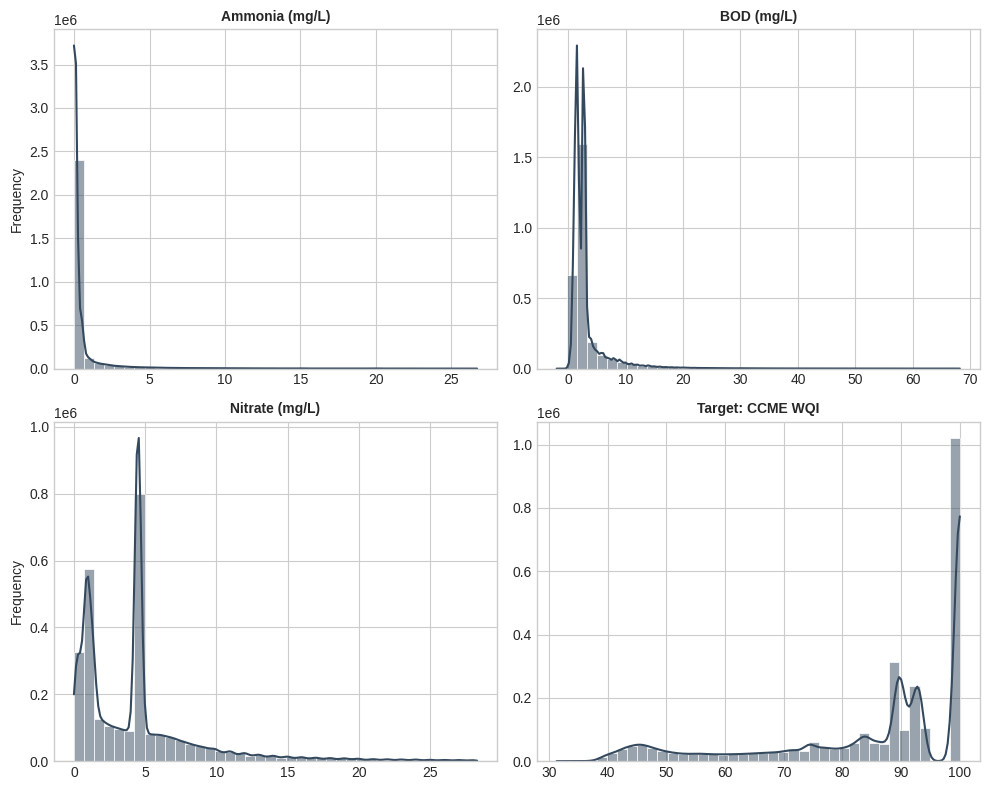

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# COMPACT DISTRIBUTION PLOT (Top 4 Features Only)
print("Generating Compact Feature Distributions...")
fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # Smaller size
axes = axes.flatten()

# Only plot the most scientifically relevant columns
key_cols = ["Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Nitrate_mg_l", "CCME_Values"]
titles = ["Ammonia (mg/L)", "BOD (mg/L)", "Nitrate (mg/L)", "Target: CCME WQI"]

for i, col in enumerate(key_cols):
    # 99th Percentile Clipping for the chemical pollutants
    if col != "CCME_Values":
        limit = df[col].quantile(0.99)
        data = df[col][df[col] <= limit]
    else:
        data = df[col] # Keep WQI as is

    sns.histplot(data, bins=40, kde=True, ax=axes[i], color='#34495e', edgecolor='white', linewidth=0.5)
    axes[i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency' if i%2==0 else '') # Only show Y-label on left plots

plt.tight_layout()
plt.savefig("Figure6_Compact_Dist.png", dpi=300)
plt.show()

In [ ]:
import joblib

full_pipeline = {
    "xgb": model_xgb,
    "cat": model_cat,
    "lgb": model_lgb,
    "rf": model_rf,
    "meta_model": meta_model,
    "scaler": scaler,
    "imputer": imputer
}

joblib.dump(full_pipeline, "/content/drive/MyDrive/wqi_full_stack.pkl")